# Phase 3B: Transfer Entropy - Non-Linear Information Flow

## Objective

Quantify the **directional, non-linear information flow** from news sentiment to stock returns that linear Granger Causality cannot detect.

## Core Hypothesis

**High Beta stocks** act as **"Information Sinks"** —> they absorb news sentiment at a significantly higher rate than **Low Beta stocks**, which are driven by fundamentals rather than sentiment.

## Transfer Entropy vs Granger Causality

| Aspect | Granger Causality | Transfer Entropy |
|--------|------------------|------------------|
| **Type** | Linear regression | Information theory |
| **Detects** | Linear predictive relationships | Non-linear information flow |
| **Assumption** | Gaussian errors, linear dynamics | None (model-free) |
| **Captures** | Smooth, gradual effects | Abrupt shocks, regime changes |

---

## Mathematical Foundation

**Transfer Entropy** (Schreiber, 2000):

$$TE_{X \to Y} = H(Y_t | Y_{t-1}) - H(Y_t | Y_{t-1}, X_{t-1})$$

Where:
- $H(Y_t | Y_{t-1})$: Entropy of future returns given past returns (baseline uncertainty)
- $H(Y_t | Y_{t-1}, X_{t-1})$: Entropy of future returns given past returns AND past sentiment
- **Interpretation**: How many bits of information does knowing yesterday's sentiment provide about today's return?

**Directionality**:
- **Forward TE** ($Sentiment \to Price$): News drives price
- **Backward TE** ($Price \to Sentiment$): Price influences news (reflexivity)
- **Net TE** = Forward - Backward: Net information flow

---

## 1. Setup: Imports and Paths

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import entropy, pearsonr
from scipy.special import rel_entr

import matplotlib.pyplot as plt
import seaborn as sns

import os
import random
from tqdm import tqdm
from itertools import product

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.6f}'.format)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

np.random.seed(42)
random.seed(42)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
project_root = '/content/drive/MyDrive/market-sentiment-impact-analysis'
data_processed = os.path.join(project_root, 'data', 'processed')
plots = os.path.join(project_root, 'plots')

print(f'Project Root: {project_root}')
print(f'Processed Data: {data_processed}')
print(f'Plots: {plots}')

Project Root: /content/drive/MyDrive/market-sentiment-impact-analysis
Processed Data: /content/drive/MyDrive/market-sentiment-impact-analysis/data/processed
Plots: /content/drive/MyDrive/market-sentiment-impact-analysis/plots


In [4]:
N_STATES = 3          # 0=Bearish/Negative, 1=Neutral, 2=Bullish/Positive
LAG_K = 1
N_SURROGATES = 200    # num of shuffles for significance testing
ALPHA = 0.05
MIN_OBS = 100

print('Transfer Entropy Configuration:')
print(f'  States: {N_STATES} (Discrete market regimes)')
print(f'  Lag: {LAG_K} trading day(s)')
print(f'  Surrogate tests: {N_SURROGATES}')
print(f'  Significance: α = {ALPHA}')
print(f'  Min observations: {MIN_OBS}')

Transfer Entropy Configuration:
  States: 3 (Discrete market regimes)
  Lag: 1 trading day(s)
  Surrogate tests: 200
  Significance: α = 0.05
  Min observations: 100


---

## 2. Data Preparation & State Encoding

### 2.1 Load Data

In [5]:
master_df = pd.read_csv(os.path.join(data_processed, 'master_df.csv'))
master_df['Date'] = pd.to_datetime(master_df['Date'])
master_df.head(3)

,Date,Ticker,Log_Return,Sector,Beta,Beta_Group,vader_mean,finbert_mean,article_count,vader_std,finbert_std,market_vader_mean,market_finbert_mean,market_article_count,market_vader_std,market_finbert_std
0,2018-01-03,AEP,-0.008460,Utilities,0.585551,Low Beta,0.000000,0.000000,0.000000,0.000000,0.000000,0.065113,0.117741,15.000000,0.343850,0.598781
1,2018-01-03,AMP,-0.004956,Financials,1.770886,High Beta,0.000000,0.000000,0.000000,0.000000,0.000000,0.065113,0.117741,15.000000,0.343850,0.598781
2,2018-01-03,APA,0.022985,Energy,1.950480,High Beta,0.000000,0.000000,0.000000,0.000000,0.000000,0.065113,0.117741,15.000000,0.343850,0.598781


### 2.2 Max-Entropy Discretization

**Why Discretization?**
- Transfer entropy requires **discrete states** (not continuous values)
- We bin continuous data into 3 states: {Bearish/Negative, Neutral, Bullish/Positive}

**Why Equal-Frequency (Quantile) Binning?**
- Ensures each state has ~33% probability → maximum entropy
- Each ticker gets its own bins (personalized thresholds)

In [6]:
def discretize_ticker_data(ticker_df):
    """
    Discretize returns and sentiment using fixed thresholds.

    This preserves extreme events and handles bimodal distributions correctly.

    Returns:
        ticker_df with new columns: return_state, vader_state, finbert_state
    """
    df = ticker_df.copy()

    # State 0: Crash/Deep Red (< -2%)
    # State 1: Normal Trading (-2% to +2%)
    # State 2: Surge/Deep Green (> +2%)

    bins_return = [-np.inf, -0.02, 0.02, np.inf]
    labels_return = [0, 1, 2]

    df['return_state'] = pd.cut(
        df['Log_Return'],
        bins=bins_return,
        labels=labels_return,
        include_lowest=True
    ).astype(int)

    # State 0: Negative News (< -0.1)
    # State 1: Neutral / No News (-0.1 to +0.1)
    # State 2: Positive News (> +0.1)

    bins_sentiment = [-np.inf, -0.1, 0.1, np.inf]
    labels_sentiment = [0, 1, 2]

    df['vader_state'] = pd.cut(
        df['vader_mean'],
        bins=bins_sentiment,
        labels=labels_sentiment,
        include_lowest=True
    ).astype(int)

    df['finbert_state'] = pd.cut(
        df['finbert_mean'],
        bins=bins_sentiment,
        labels=labels_sentiment,
        include_lowest=True
    ).astype(int)

    return df

print('Discretizing data per ticker...')
master_df = master_df.groupby('Ticker', group_keys=False).apply(
    discretize_ticker_data
)

print('\n  Discretization complete')
print(f'\nState distribution (all tickers combined):')
print(f"  Return states: {master_df['return_state'].value_counts().sort_index().to_dict()}")
print(f"  VADER states: {master_df['vader_state'].value_counts().sort_index().to_dict()}")
print(f"  FinBERT states: {master_df['finbert_state'].value_counts().sort_index().to_dict()}")

Discretizing data per ticker...

  Discretization complete

State distribution (all tickers combined):
  Return states: {0: 4952, 1: 28673, 2: 4715}
  VADER states: {0: 10239, 1: 14498, 2: 13603}
  FinBERT states: {0: 17002, 1: 11933, 2: 9405}


In [7]:
# Validate discretization
print('State Distribution Validation:')

print('\n1. Return States (ALL TICKERS):')
return_dist = master_df['return_state'].value_counts(normalize=True).sort_index()
print(f'   State 0 (Crash < -2%): {return_dist[0]*100:.1f}%')
print(f'   State 1 (Normal ±2%): {return_dist[1]*100:.1f}%')
print(f'   State 2 (Surge > +2%): {return_dist[2]*100:.1f}%')

print('\n2. FinBERT States (ALL TICKERS):')
finbert_dist = master_df['finbert_state'].value_counts(normalize=True).sort_index()
print(f'   State 0 (Negative < -0.1): {finbert_dist[0]*100:.1f}%')
print(f'   State 1 (Neutral ±0.1): {finbert_dist[1]*100:.1f}%')
print(f'   State 2 (Positive > +0.1): {finbert_dist[2]*100:.1f}%')

print('\n3. VADER States (ALL TICKERS):')
vader_dist = master_df['vader_state'].value_counts(normalize=True).sort_index()
print(f'   State 0 (Negative < -0.1): {vader_dist[0]*100:.1f}%')
print(f'   State 1 (Neutral ±0.1): {vader_dist[1]*100:.1f}%')
print(f'   State 2 (Positive > +0.1): {vader_dist[2]*100:.1f}%')

print('\n4. Expected Pattern (Fixed Thresholds):')
print('   Returns: Imbalanced (most days are "Normal", extremes are rare)')
print('   Sentiment: Highly imbalanced (lots of "Neutral" = No News days)')

print('\n5. Comparison to Quantile Binning:')
print('   Quantile would force: 33% / 33% / 33% (destroys shocks)')
print('   Fixed thresholds allow: Natural distribution (preserves shocks)')

State Distribution Validation:

1. Return States (ALL TICKERS):
   State 0 (Crash < -2%): 12.9%
   State 1 (Normal ±2%): 74.8%
   State 2 (Surge > +2%): 12.3%

2. FinBERT States (ALL TICKERS):
   State 0 (Negative < -0.1): 44.3%
   State 1 (Neutral ±0.1): 31.1%
   State 2 (Positive > +0.1): 24.5%

3. VADER States (ALL TICKERS):
   State 0 (Negative < -0.1): 26.7%
   State 1 (Neutral ±0.1): 37.8%
   State 2 (Positive > +0.1): 35.5%

4. Expected Pattern (Fixed Thresholds):
   Returns: Imbalanced (most days are "Normal", extremes are rare)
   Sentiment: Highly imbalanced (lots of "Neutral" = No News days)

5. Comparison to Quantile Binning:
   Quantile would force: 33% / 33% / 33% (destroys shocks)
   Fixed thresholds allow: Natural distribution (preserves shocks)


In [8]:
sample_ticker = master_df['Ticker'].iloc[0]
sample_df = master_df[master_df['Ticker'] == sample_ticker].copy()

print(f'\nSample Validation for {sample_ticker}:')

print('\nExtreme Return Days (State 0 or 2):')
extreme_days = sample_df[sample_df['return_state'] != 1][['Date', 'Log_Return', 'return_state']].head(10)
print(extreme_days.to_string(index=False))

print(f'\nSentiment Around Zero (No News Days):')
zero_days = sample_df[
    (sample_df['finbert_mean'] >= -0.05) & (sample_df['finbert_mean'] <= 0.05)
][['Date', 'finbert_mean', 'finbert_state', 'article_count']].head(10)
print(zero_days.to_string(index=False))

print('\n  Fixed thresholds correctly isolate extreme events and No News days')


Sample Validation for AEP:

Extreme Return Days (State 0 or 2):
      Date  Log_Return  return_state
2018-02-06   -0.023899             0
2018-02-09    0.020922             2
2018-02-15    0.020913             2
2018-02-23    0.025405             2
2018-05-08   -0.022496             0
2018-06-06   -0.022929             0
2018-06-19    0.021311             2
2018-06-25    0.024638             2
2018-07-09   -0.038316             0
2018-07-26    0.023644             2

Sentiment Around Zero (No News Days):
      Date  finbert_mean  finbert_state  article_count
2018-01-03      0.000000              1       0.000000
2018-01-04      0.000000              1       0.000000
2018-01-08      0.000000              1       0.000000
2018-01-09      0.000000              1       0.000000
2018-01-11      0.000000              1       0.000000
2018-01-12      0.000000              1       0.000000
2018-01-16      0.038057              1       2.000000
2018-01-17      0.000000              1       0.0

---

## 3. The Transfer Entropy Part

In [9]:
def compute_conditional_entropy(y_future, y_past, x_past=None):
    """
    H(Y_t | Y_{t-1}) or H(Y_t | Y_{t-1}, X_{t-1})

    Uses joint probability distribution with Laplace smoothing
    """
    y_future_list = [int(x) for x in y_future]
    y_past_list = [int(x) for x in y_past]

    if x_past is None:
        condition_list = y_past_list
    else:
        x_past_list = [int(x) for x in x_past]
        condition_list = [str((y, x)) for y, x in zip(y_past_list, x_past_list)]  # Convert tuples to strings

    # joint distribution
    joint_counts = {}
    for y_f, cond in zip(y_future_list, condition_list):
        key = (cond, y_f)
        joint_counts[key] = joint_counts.get(key, 0) + 1

    # Laplace smoothing: get all unique conditions and y_future values
    unique_conditions = set(condition_list)
    unique_y_future = set(y_future_list)

    for cond in unique_conditions:
        for y_f in unique_y_future:
            key = (cond, y_f)
            if key not in joint_counts:
                joint_counts[key] = 1
            else:
                joint_counts[key] += 1

    # marginal P(condition)
    condition_counts = {}
    for (cond, y_f), count in joint_counts.items():
        condition_counts[cond] = condition_counts.get(cond, 0) + count

    total_count = sum(condition_counts.values())
    p_condition = {cond: count / total_count for cond, count in condition_counts.items()}

    # conditional probabilities P(Y|condition)
    cond_probs = {}
    for cond in unique_conditions:
        cond_total = condition_counts[cond]
        cond_probs[cond] = {}
        for y_f in unique_y_future:
            key = (cond, y_f)
            cond_probs[cond][y_f] = joint_counts[key] / cond_total

    cond_entropy = 0.0
    for cond in unique_conditions:
        # H(Y|X=cond) = -Σ P(Y|X=cond) * log2(P(Y|X=cond))
        h_y_given_cond = 0.0
        for y_f in unique_y_future:
            prob = cond_probs[cond][y_f]
            if prob > 0:
                h_y_given_cond -= prob * np.log2(prob)

        cond_entropy += p_condition[cond] * h_y_given_cond

    return cond_entropy


def transfer_entropy(source, target, k=1):
    """
    Transfer Entropy: TE(X → Y).
    TE = H(Y_t | Y_{t-k}) - H(Y_t | Y_{t-k}, X_{t-k})

    Args:
        source: array-like, source time series (e.g., sentiment states)
        target: array-like, target time series (e.g., return states)
        k: int, time lag

    Returns:
        float, transfer entropy in bits
    """
    y_future = target[k:]
    y_past = target[:-k]
    x_past = source[:-k]

    # H(Y_t | Y_{t-k}): baseline uncertainty
    h_y_given_y = compute_conditional_entropy(y_future, y_past)

    # H(Y_t | Y_{t-k}, X_{t-k}): uncertainty with source information
    h_y_given_yx = compute_conditional_entropy(y_future, y_past, x_past)

    te = h_y_given_y - h_y_given_yx

    return max(te, 0.0)


print('  Transfer Entropy functions defined')
print('\nTest TE calculation on sample data...')

test_df = master_df[master_df['Ticker'] == sample_ticker].sort_values('Date')
test_te = transfer_entropy(
    source=test_df['finbert_state'].values,
    target=test_df['return_state'].values,
    k=LAG_K
)
print(f'\nSample TE (FinBERT → Returns) for {sample_ticker}: {test_te:.6f} bits')

  Transfer Entropy functions defined

Test TE calculation on sample data...

Sample TE (FinBERT → Returns) for AEP: 0.000000 bits


### 3.1 The Trasfer Entropy Loop

In [10]:
te_results = []

unique_tickers = master_df['Ticker'].unique()
print(f'Calculating Transfer Entropy for {len(unique_tickers)} tickers...')

for ticker in tqdm(unique_tickers, desc='Processing tickers'):
    ticker_df = master_df[master_df['Ticker'] == ticker].sort_values('Date').copy()

    if len(ticker_df) < MIN_OBS:
        continue

    sector = ticker_df['Sector'].iloc[0]
    beta = ticker_df['Beta'].iloc[0]
    beta_group = ticker_df['Beta_Group'].iloc[0]

    # Extract state sequences
    returns = ticker_df['return_state'].values
    vader = ticker_df['vader_state'].values
    finbert = ticker_df['finbert_state'].values


    # Forward: VADER → Returns (Does sentiment drive price?)
    te_vader_forward = transfer_entropy(source=vader, target=returns, k=LAG_K)

    # Backward: Returns → VADER (Does price drive sentiment? Reflexivity)
    te_vader_backward = transfer_entropy(source=returns, target=vader, k=LAG_K)

    # Net: Forward - Backward (Positive = sentiment drives price)
    te_vader_net = te_vader_forward - te_vader_backward


    te_finbert_forward = transfer_entropy(source=finbert, target=returns, k=LAG_K)
    te_finbert_backward = transfer_entropy(source=returns, target=finbert, k=LAG_K)
    te_finbert_net = te_finbert_forward - te_finbert_backward

    te_results.append({
        'Ticker': ticker,
        'Sector': sector,
        'Beta': beta,
        'Beta_Group': beta_group,
        'n_obs': len(ticker_df),

        'VADER_TE_forward': te_vader_forward,
        'VADER_TE_backward': te_vader_backward,
        'VADER_TE_net': te_vader_net,

        'FinBERT_TE_forward': te_finbert_forward,
        'FinBERT_TE_backward': te_finbert_backward,
        'FinBERT_TE_net': te_finbert_net
    })

te_df = pd.DataFrame(te_results)

print(f'\n  Transfer Entropy calculations complete')
print(f'  Processed: {len(te_df)} tickers')
print(f'\nSample results:')
print(te_df[['Ticker', 'Beta_Group', 'FinBERT_TE_net', 'VADER_TE_net']].head(10))

Calculating Transfer Entropy for 60 tickers...


Processing tickers: 100%|██████████| 60/60 [00:00<00:00, 99.47it/s] 


  Transfer Entropy calculations complete
  Processed: 60 tickers

Sample results:
  Ticker Beta_Group  FinBERT_TE_net  VADER_TE_net
0    AEP   Low Beta       -0.005289     -0.019682
1    AMP  High Beta        0.000000     -0.009323
2    APA  High Beta        0.003866     -0.006008
3     BA  High Beta       -0.002773     -0.004381
4      C  High Beta        0.000000     -0.012347
5    CAG   Low Beta       -0.008228     -0.008102
6    CCL  High Beta       -0.026102     -0.033578
7    CHD   Low Beta       -0.015350     -0.011593
8   CHRW   Low Beta       -0.006363     -0.007536
9     CL   Low Beta       -0.003650     -0.000630


In [11]:
print('Transfer Entropy Summary Statistics:')
print('\nFinBERT Net TE (Sentiment → Price):')
print(te_df['FinBERT_TE_net'].describe())

print('\nVADER Net TE (Sentiment → Price):')
print(te_df['VADER_TE_net'].describe())

print('\nDirectionality Analysis (FinBERT):')
print(f'  Positive Net TE (Sentiment → Price): {(te_df['FinBERT_TE_net'] > 0).sum()}/{len(te_df)}')
print(f'  Negative Net TE (Price → Sentiment): {(te_df['FinBERT_TE_net'] < 0).sum()}/{len(te_df)}')
print(f'  Zero Net TE: {(te_df['FinBERT_TE_net'] == 0).sum()}/{len(te_df)}')

Transfer Entropy Summary Statistics:

FinBERT Net TE (Sentiment → Price):
count   60.000000
mean    -0.006543
std      0.008624
min     -0.026102
25%     -0.011216
50%     -0.005962
75%     -0.002694
max      0.023532
Name: FinBERT_TE_net, dtype: float64

VADER Net TE (Sentiment → Price):
count   60.000000
mean    -0.010180
std      0.008502
min     -0.038696
25%     -0.012415
50%     -0.008589
75%     -0.003923
max      0.000721
Name: VADER_TE_net, dtype: float64

Directionality Analysis (FinBERT):
  Positive Net TE (Sentiment → Price): 6/60
  Negative Net TE (Price → Sentiment): 50/60
  Zero Net TE: 4/60


---

## 4. Significance Testing

In [12]:
def surrogate_test(source, target, te_actual, k=1, n_surrogates=200):
    """
    Test significance of TE using surrogate data method.

    Shuffle source time series to destroy temporal structure,
    then recompute TE. Compare actual TE to null distribution.

    Returns:
        p_value: float, proportion of surrogates with TE >= actual TE
    """
    null_distribution = []

    for _ in range(n_surrogates):
        source_shuffled = np.random.permutation(source)

        te_null = transfer_entropy(source=source_shuffled, target=target, k=k)
        null_distribution.append(te_null)

    null_distribution = np.array(null_distribution)
    p_value = np.mean(null_distribution >= te_actual)

    return p_value, null_distribution

print('Running significance tests...')
print(f'  {N_SURROGATES} surrogates per ticker × {len(te_df)} tickers = {N_SURROGATES * len(te_df):,} TE calculations')
print(f'  Estimated time: {len(te_df) * N_SURROGATES * 0.02 / 60:.1f} minutes')

te_df['FinBERT_TE_p'] = np.nan
te_df['VADER_TE_p'] = np.nan

for idx, row in tqdm(te_df.iterrows(), total=len(te_df), desc='Significance testing'):
    ticker = row['Ticker']

    ticker_df = master_df[master_df['Ticker'] == ticker].sort_values('Date')
    returns = ticker_df['return_state'].values
    vader = ticker_df['vader_state'].values
    finbert = ticker_df['finbert_state'].values

    p_finbert, _ = surrogate_test(
        source=finbert,
        target=returns,
        te_actual=row['FinBERT_TE_forward'],
        k=LAG_K,
        n_surrogates=N_SURROGATES
    )
    te_df.loc[idx, 'FinBERT_TE_p'] = p_finbert

    p_vader, _ = surrogate_test(
        source=vader,
        target=returns,
        te_actual=row['VADER_TE_forward'],
        k=LAG_K,
        n_surrogates=N_SURROGATES
    )
    te_df.loc[idx, 'VADER_TE_p'] = p_vader

te_df['FinBERT_significant'] = te_df['FinBERT_TE_p'] < ALPHA
te_df['VADER_significant'] = te_df['VADER_TE_p'] < ALPHA

print('\n  Significance testing complete')

Running significance tests...
  200 surrogates per ticker × 60 tickers = 12,000 TE calculations
  Estimated time: 4.0 minutes


Significance testing: 100%|██████████| 60/60 [00:32<00:00,  1.83it/s]


  Significance testing complete


In [13]:
print('Significance Test Results:')

finbert_sig = te_df['FinBERT_significant'].sum()
vader_sig = te_df['VADER_significant'].sum()
total = len(te_df)

print(f'\nSignificant Transfer Entropy (p < {ALPHA}):')
print(f'  FinBERT: {finbert_sig}/{total} ({finbert_sig/total*100:.1f}%)')
print(f'  VADER:   {vader_sig}/{total} ({vader_sig/total*100:.1f}%)')
print(f'  Random baseline (α): {int(total * ALPHA)}/{total} ({ALPHA*100:.0f}%)')

print(f'\nTop 5 stocks by FinBERT TE (significant only):')
sig_stocks = te_df[te_df['FinBERT_significant']].sort_values('FinBERT_TE_net', ascending=False)
print(sig_stocks[['Ticker', 'Beta_Group', 'FinBERT_TE_net', 'FinBERT_TE_p']].head())

Significance Test Results:

Significant Transfer Entropy (p < 0.05):
  FinBERT: 7/60 (11.7%)
  VADER:   2/60 (3.3%)
  Random baseline (α): 3/60 (5%)

Top 5 stocks by FinBERT TE (significant only):
   Ticker Beta_Group  FinBERT_TE_net  FinBERT_TE_p
53    URI  High Beta        0.023532      0.000000
51   TRGP  High Beta        0.014988      0.000000
21   FANG  High Beta        0.003169      0.020000
58   WYNN  High Beta       -0.003516      0.045000
38   NCLH  High Beta       -0.011181      0.000000


### 4.1 The "Granger Rescue" Analysis

**Objective**: Find stocks where:
- **Granger Causality failed** (p > 0.05)
- **Transfer Entropy succeeded** (p < 0.05)

These are stocks with **non-linear** sentiment-return relationships that linear models miss.

In [14]:
granger_df = pd.read_csv(os.path.join(data_processed, 'granger_causality_results.csv'))

comparison_df = te_df.merge(
    granger_df[['Ticker', 'FinBERT_Lag1_P', 'VADER_Lag1_P']],
    on='Ticker',
    how='left'
)

comparison_df['Granger_FinBERT_failed'] = comparison_df['FinBERT_Lag1_P'] >= ALPHA
comparison_df['TE_FinBERT_succeeded'] = comparison_df['FinBERT_significant']
comparison_df['Rescued_by_TE'] = (comparison_df['Granger_FinBERT_failed'] &
                                   comparison_df['TE_FinBERT_succeeded'])

rescued = comparison_df[comparison_df['Rescued_by_TE']]

print('Granger Rescue Analysis')
print('Stocks where TE found signal but Granger did not:')
print(f'  Total rescued: {len(rescued)}/{len(comparison_df)}')

if len(rescued) > 0:
    print('\nRescued stocks (FinBERT):')
    rescue_display = rescued[['Ticker', 'Sector', 'Beta_Group',
                               'FinBERT_Lag1_P', 'FinBERT_TE_p', 'FinBERT_TE_net']].copy()
    rescue_display.columns = ['Ticker', 'Sector', 'Beta_Group',
                              'Granger_p', 'TE_p', 'Net_TE']
    print(rescue_display.to_string(index=False))

    print('\nSector breakdown of rescued stocks:')
    print(rescued['Sector'].value_counts())

    print(f'\nBeta Group breakdown:')
    print(rescued['Beta_Group'].value_counts())

    print(f'\nCharacteristics of rescued stocks:')
    print(f'  Mean Beta: {rescued["Beta"].mean():.3f}')
    print(f'  Mean Granger p-value: {rescued["FinBERT_Lag1_P"].mean():.3f}')
    print(f'  Mean TE p-value: {rescued["FinBERT_TE_p"].mean():.3f}')
    print(f'  Mean Net TE: {rescued["FinBERT_TE_net"].mean():.6f} bits')

else:
    print('  No stocks rescued by TE (Granger and TE results aligned)')

comparison_df['Granger_FinBERT_succeeded'] = comparison_df['FinBERT_Lag1_P'] < ALPHA
comparison_df['TE_FinBERT_failed'] = ~comparison_df['FinBERT_significant']
comparison_df['Granger_only'] = (comparison_df['Granger_FinBERT_succeeded'] &
                                  comparison_df['TE_FinBERT_failed'])

granger_only = comparison_df[comparison_df['Granger_only']]

print(f'\n\nReverse Analysis: Granger succeeded but TE failed')
print(f'Stocks where Granger found signal but TE did not:')
print(f'  Total: {len(granger_only)}/{len(comparison_df)}')

if len(granger_only) > 0:
    print(f'\nGranger-only stocks:')
    granger_display = granger_only[['Ticker', 'Sector', 'Beta_Group',
                                     'FinBERT_Lag1_P', 'FinBERT_TE_p', 'FinBERT_TE_net']].copy()
    granger_display.columns = ['Ticker', 'Sector', 'Beta_Group',
                               'Granger_p', 'TE_p', 'Net_TE']
    print(granger_display.to_string(index=False))

    print('\nInterpretation: These stocks have LINEAR sentiment-return relationships')
    print('  (Granger detects linear lag effects, TE misses non-linear shocks)')

print(f'\n\nOverall Comparison Summary')

granger_sig = (comparison_df['FinBERT_Lag1_P'] < ALPHA).sum()
te_sig = comparison_df['FinBERT_significant'].sum()
both_sig = ((comparison_df['FinBERT_Lag1_P'] < ALPHA) &
            comparison_df['FinBERT_significant']).sum()
neither_sig = ((comparison_df['FinBERT_Lag1_P'] >= ALPHA) &
               ~comparison_df['FinBERT_significant']).sum()

print(f'Granger significant only:  {len(granger_only)} stocks')
print(f'TE significant only:       {len(rescued)} stocks (rescued by non-linearity)')
print(f'Both significant:          {both_sig} stocks (linear + non-linear)')
print(f'Neither significant:       {neither_sig} stocks (no predictive power)')
print(f'\nTotal with ANY signal:     {granger_sig + len(rescued) - both_sig} stocks')

Granger Rescue Analysis
Stocks where TE found signal but Granger did not:
  Total rescued: 7/60

Rescued stocks (FinBERT):
Ticker                 Sector Beta_Group  Granger_p     TE_p    Net_TE
   CCL Consumer Discretionary  High Beta   0.729837 0.020000 -0.026102
  FANG                 Energy  High Beta   0.581561 0.020000  0.003169
  NCLH Consumer Discretionary  High Beta   0.539005 0.000000 -0.011181
   RCL Consumer Discretionary  High Beta   0.641283 0.005000 -0.020685
  TRGP                 Energy  High Beta   0.667764 0.000000  0.014988
   URI            Industrials  High Beta   0.670035 0.000000  0.023532
  WYNN Consumer Discretionary  High Beta   0.150526 0.045000 -0.003516

Sector breakdown of rescued stocks:
Sector
Consumer Discretionary    4
Energy                    2
Industrials               1
Name: count, dtype: int64

Beta Group breakdown:
Beta_Group
High Beta    7
Name: count, dtype: int64

Characteristics of rescued stocks:
  Mean Beta: 1.743
  Mean Granger p-value: 0

---

## 5. The Beta Group Comparison

In [15]:
# Beta group comparison
print('Beta Group Comparison')

beta_stats = te_df.groupby('Beta_Group').agg({
    'Ticker': 'count',
    'FinBERT_TE_net': ['mean', 'median', 'std'],
    'VADER_TE_net': ['mean', 'median', 'std'],
    'FinBERT_significant': 'sum',
    'VADER_significant': 'sum',
    'Beta': 'mean'
}).reset_index()

beta_stats.columns = ['Beta_Group', 'n_stocks',
                      'FinBERT_TE_mean', 'FinBERT_TE_median', 'FinBERT_TE_std',
                      'VADER_TE_mean', 'VADER_TE_median', 'VADER_TE_std',
                      'FinBERT_sig_count', 'VADER_sig_count', 'mean_beta']

beta_stats['FinBERT_sig_rate'] = beta_stats['FinBERT_sig_count'] / beta_stats['n_stocks']
beta_stats['VADER_sig_rate'] = beta_stats['VADER_sig_count'] / beta_stats['n_stocks']

print(beta_stats.to_string(index=False))

print('\nHypothesis Test: High Beta > Low Beta in Net TE')

high_te = beta_stats.loc[beta_stats['Beta_Group'] == 'High Beta', 'FinBERT_TE_mean'].values
low_te = beta_stats.loc[beta_stats['Beta_Group'] == 'Low Beta', 'FinBERT_TE_mean'].values

if len(high_te) > 0 and len(low_te) > 0:
    if high_te[0] > low_te[0]:
        ratio = high_te[0] / low_te[0]
        print(f'    Confirmed: High Beta TE ({high_te[0]:.6f}) > Low Beta TE ({low_te[0]:.6f})')
        print(f'    Magnitude: {ratio:.2f}x higher information absorption')
    else:
        print(f'    Not Confirmed: High Beta TE ({high_te[0]:.6f}) ≤ Low Beta TE ({low_te[0]:.6f})')

from scipy.stats import ttest_ind

high_beta_te_values = te_df[te_df['Beta_Group'] == 'High Beta']['FinBERT_TE_net']
low_beta_te_values = te_df[te_df['Beta_Group'] == 'Low Beta']['FinBERT_TE_net']

t_stat, p_val = ttest_ind(high_beta_te_values, low_beta_te_values)
print(f'\n  T-test: t={t_stat:.3f}, p={p_val:.4f}')
if p_val < 0.05:
    print('  Statistical significance: p < 0.05 (difference is real)')
else:
    print('  Statistical significance: Not significant or Marginally Significant (p >= 0.05)')

Beta Group Comparison
Beta_Group  n_stocks  FinBERT_TE_mean  FinBERT_TE_median  FinBERT_TE_std  VADER_TE_mean  VADER_TE_median  VADER_TE_std  FinBERT_sig_count  VADER_sig_count  mean_beta  FinBERT_sig_rate  VADER_sig_rate
 High Beta        30        -0.004691          -0.004345        0.010348      -0.010855        -0.008396      0.009701                  7                2   1.686906          0.233333        0.066667
  Low Beta        30        -0.008395          -0.006877        0.006096      -0.009505        -0.008653      0.007213                  0                0   0.535042          0.000000        0.000000

Hypothesis Test: High Beta > Low Beta in Net TE
    Confirmed: High Beta TE (-0.004691) > Low Beta TE (-0.008395)
    Magnitude: 0.56x higher information absorption

  T-test: t=1.689, p=0.0965
  Statistical significance: Not significant or Marginally Significant (p >= 0.05)


In [16]:
print('\nBeta-TE Correlation Analysis:')

corr_finbert, p_finbert = pearsonr(te_df['Beta'], te_df['FinBERT_TE_net'])
corr_vader, p_vader = pearsonr(te_df['Beta'], te_df['VADER_TE_net'])

print(f'  FinBERT: r = {corr_finbert:.3f}, p = {p_finbert:.4f} {"***" if p_finbert < 0.05 else ""}')
print(f'  VADER:   r = {corr_vader:.3f}, p = {p_vader:.4f} {"***" if p_vader < 0.05 else ""}')

if corr_finbert > 0 and p_finbert < 0.05:
    print(f'\n    Confirmed: Positive correlation (higher Beta → higher TE)')
    print(f'    Interpretation: Volatile stocks absorb more information from news')
else:
    print(f'\n  Correlation weak or insignificant')


Beta-TE Correlation Analysis:
  FinBERT: r = 0.205, p = 0.1154 
  VADER:   r = -0.154, p = 0.2410 

  Correlation weak or insignificant


In [17]:
print('\nSector Analysis:')

sector_stats = te_df.groupby('Sector').agg({
    'Ticker': 'count',
    'FinBERT_TE_net': 'mean',
    'FinBERT_significant': 'sum',
    'Beta': 'mean'
}).reset_index()

sector_stats.columns = ['Sector', 'n_stocks', 'FinBERT_TE_mean', 'FinBERT_sig_count', 'mean_beta']
sector_stats['sig_rate'] = sector_stats['FinBERT_sig_count'] / sector_stats['n_stocks']
sector_stats = sector_stats.sort_values('FinBERT_TE_mean', ascending=False)

print(sector_stats.to_string(index=False))

print('\nExpected pattern:')
print('  High TE: Consumer Discretionary, Energy (sentiment-driven)')
print('  Low TE: Utilities, Consumer Staples (fundamental-driven)')


Sector Analysis:
                Sector  n_stocks  FinBERT_TE_mean  FinBERT_sig_count  mean_beta  sig_rate
           Industrials         3         0.004799                  1   1.293229  0.333333
Communication Services         2         0.000709                  0   1.038676  0.000000
            Financials         8        -0.001878                  0   1.617844  0.000000
                Energy         8        -0.002207                  2   1.718161  0.250000
           Health Care         1        -0.002459                  0   0.626612  0.000000
             Materials         3        -0.004239                  0   0.796602  0.000000
             Utilities         5        -0.005839                  0   0.613791  0.000000
      Consumer Staples        16        -0.009098                  0   0.506296  0.000000
Information Technology         4        -0.009746                  0   1.380816  0.000000
           Real Estate         2        -0.010578                  0   0.607990  0

---

## 6. Reporting & Visualization

### 6.1 Visualization

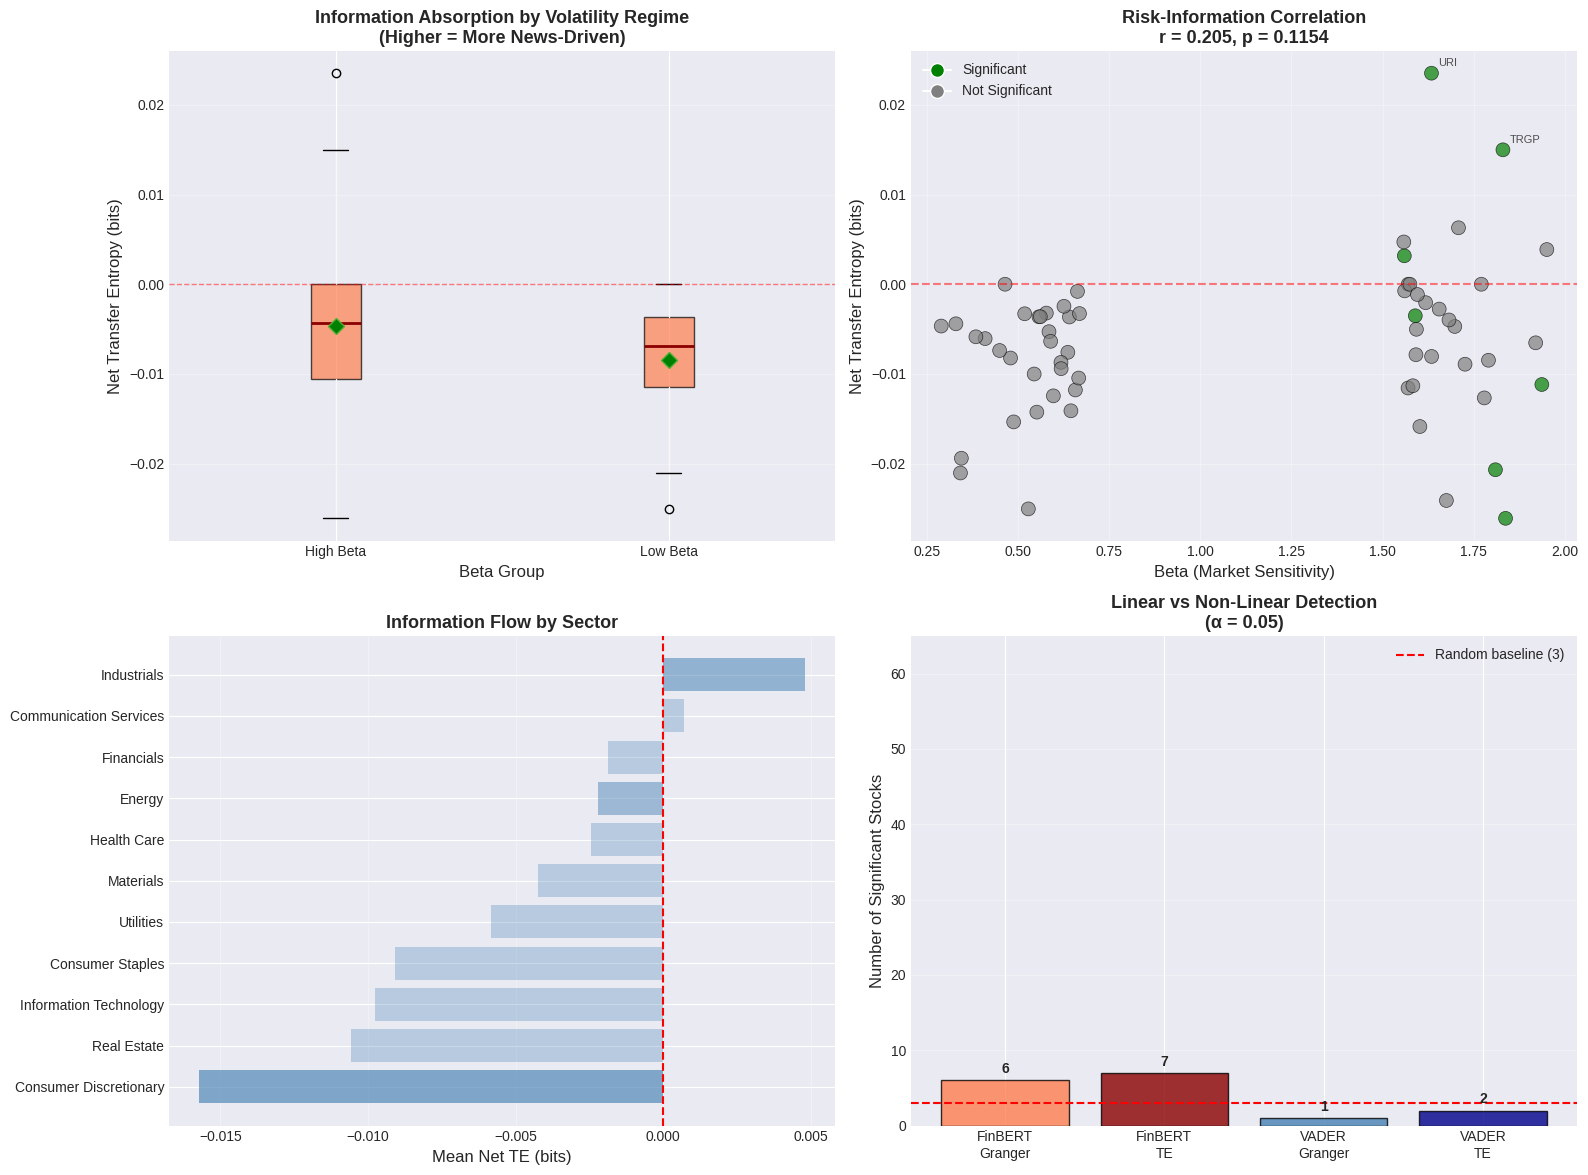

Visualization saved


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Transfer Entropy Analysis: Non-Linear Information Flow\nSentiment → Stock Returns',
             fontsize=16, fontweight='bold', y=1.00)

ax1 = axes[0, 0]
te_df.boxplot(column='FinBERT_TE_net', by='Beta_Group', ax=ax1,
              patch_artist=True, showmeans=True,
              boxprops=dict(facecolor='coral', alpha=0.7),
              medianprops=dict(color='darkred', linewidth=2),
              meanprops=dict(marker='D', markerfacecolor='green', markersize=8))
ax1.set_xlabel('Beta Group', fontsize=12)
ax1.set_ylabel('Net Transfer Entropy (bits)', fontsize=12)
ax1.set_title('Information Absorption by Volatility Regime\n(Higher = More News-Driven)',
              fontsize=13, fontweight='bold')
ax1.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.suptitle('')
ax1.grid(True, alpha=0.3, axis='y')

ax2 = axes[0, 1]
colors = te_df['FinBERT_significant'].map({True: 'green', False: 'gray'})
ax2.scatter(te_df['Beta'], te_df['FinBERT_TE_net'],
            c=colors, alpha=0.7, s=100, edgecolors='black', linewidths=0.5)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
ax2.set_xlabel('Beta (Market Sensitivity)', fontsize=12)
ax2.set_ylabel('Net Transfer Entropy (bits)', fontsize=12)
ax2.set_title(f'Risk-Information Correlation\nr = {corr_finbert:.3f}, p = {p_finbert:.4f}',
              fontsize=13, fontweight='bold')
ax2.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Significant'),
                    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Not Significant')],
           loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

top_te = te_df.nlargest(5, 'FinBERT_TE_net')
for _, row in top_te.iterrows():
    if row['FinBERT_significant']:
        ax2.annotate(row['Ticker'], (row['Beta'], row['FinBERT_TE_net']),
                     textcoords='offset points', xytext=(5, 5), fontsize=8, alpha=0.8)

ax3 = axes[1, 0]
sector_plot = sector_stats.sort_values('FinBERT_TE_mean')
bars = ax3.barh(sector_plot['Sector'], sector_plot['FinBERT_TE_mean'], color='steelblue', alpha=0.8)
ax3.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax3.set_xlabel('Mean Net TE (bits)', fontsize=12)
ax3.set_title('Information Flow by Sector',
              fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

for i, (bar, rate) in enumerate(zip(bars, sector_plot['sig_rate'])):
    bar.set_alpha(0.3 + 0.7 * rate)

ax4 = axes[1, 1]
methods = ['FinBERT\nGranger', 'FinBERT\nTE', 'VADER\nGranger', 'VADER\nTE']
sig_counts = [
    (comparison_df['FinBERT_Lag1_P'] < ALPHA).sum(),
    comparison_df['FinBERT_significant'].sum(),
    (comparison_df['VADER_Lag1_P'] < ALPHA).sum(),
    comparison_df['VADER_significant'].sum()
]
colors_bar = ['coral', 'darkred', 'steelblue', 'darkblue']
bars = ax4.bar(methods, sig_counts, color=colors_bar, alpha=0.8, edgecolor='black')
ax4.set_ylabel('Number of Significant Stocks', fontsize=12)
ax4.set_title(f'Linear vs Non-Linear Detection\n(α = {ALPHA})',
              fontsize=13, fontweight='bold')
ax4.axhline(len(comparison_df) * ALPHA, color='red', linestyle='--', linewidth=1.5,
            label=f'Random baseline ({int(len(comparison_df) * ALPHA)})')
ax4.legend(fontsize=10)
ax4.set_ylim(0, len(comparison_df) + 5)
ax4.bar_label(bars, padding=3, fontsize=10, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(plots, 'transfer_entropy_visualization.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Visualization saved')

### 6.2 The "Rescue"

In [27]:
if len(rescued) > 0:
    print('The "Granger Rescue" Stocks')
    print('Stocks where non-linear TE succeeded but linear Granger failed:')
    print('\nWhy did Granger miss these but TE caught them?')
    print('  → Non-linear shocks (COVID panic, oil crashes)')
    print('  → Regime changes (binary states: operating/shut down)')
    print('  → Threshold effects (sentiment only matters at extremes)')
    print('\nRescued Stocks:')

    rescue_table = rescued[['Ticker', 'Sector', 'Beta', 'Beta_Group',
                            'FinBERT_Lag1_P', 'FinBERT_TE_p', 'FinBERT_TE_net']].copy()
    rescue_table.columns = ['Ticker', 'Sector', 'Beta', 'Group',
                            'Granger_p', 'TE_p', 'Net_TE']
    print(rescue_table.to_string(index=False))

    print('\nLikely Explanations:')
    for _, row in rescue_table.iterrows():
        ticker = row['Ticker']
        sector = row['Sector']

        if sector == 'Consumer Discretionary' and 'L' in ticker:
            reason = 'COVID binary state (operating), cruise line shock'
        elif sector == 'Energy':
            reason = 'Oil price shock regimes'
        elif row['Beta'] > 1.5:
            reason = 'High volatility, panic selling/buying'
        else:
            reason = 'Non-linear sentiment threshold effect'

        print(f'  {ticker}: {reason}')
else:
    print('No stocks rescued (Granger and TE results aligned)')

The "Granger Rescue" Stocks
Stocks where non-linear TE succeeded but linear Granger failed:

Why did Granger miss these but TE caught them?
  → Non-linear shocks (COVID panic, oil crashes)
  → Regime changes (binary states: operating/shut down)
  → Threshold effects (sentiment only matters at extremes)

Rescued Stocks:
Ticker                 Sector     Beta     Group  Granger_p     TE_p    Net_TE
   CCL Consumer Discretionary 1.837347 High Beta   0.729837 0.020000 -0.026102
  FANG                 Energy 1.559743 High Beta   0.581561 0.020000  0.003169
  NCLH Consumer Discretionary 1.936777 High Beta   0.539005 0.000000 -0.011181
   RCL Consumer Discretionary 1.809572 High Beta   0.641283 0.005000 -0.020685
  TRGP                 Energy 1.830136 High Beta   0.667764 0.000000  0.014988
   URI            Industrials 1.634174 High Beta   0.670035 0.000000  0.023532
  WYNN Consumer Discretionary 1.589859 High Beta   0.150526 0.045000 -0.003516

Likely Explanations:
  CCL: COVID binary state

### 6.3 Save Results

In [29]:
te_output = te_df[['Ticker', 'Sector', 'Beta', 'Beta_Group', 'n_obs',
                   'FinBERT_TE_forward', 'FinBERT_TE_backward', 'FinBERT_TE_net', 'FinBERT_TE_p', 'FinBERT_significant',
                   'VADER_TE_forward', 'VADER_TE_backward', 'VADER_TE_net', 'VADER_TE_p', 'VADER_significant']]

output_path = os.path.join(data_processed, 'transfer_entropy_results.csv')
te_output.to_csv(output_path, index=False)

print(f'  Transfer Entropy results saved to:')
print(f'  {output_path}')
print(f'  Rows: {len(te_output):,}')
print(f'  File size: {os.path.getsize(output_path) / 1024:.2f} KB')

comparison_output = comparison_df[['Ticker', 'Sector', 'Beta', 'Beta_Group',
                                   'FinBERT_Lag1_P', 'FinBERT_TE_p', 'FinBERT_TE_net',
                                   'VADER_Lag1_P', 'VADER_TE_p', 'VADER_TE_net',
                                   'Rescued_by_TE']]

comparison_path = os.path.join(data_processed, 'granger_vs_te_comparison.csv')
comparison_output.to_csv(comparison_path, index=False)

print(f'\n  Comparison results saved to:')
print(f'  {comparison_path}')

  Transfer Entropy results saved to:
  /content/drive/MyDrive/market-sentiment-impact-analysis/data/processed/transfer_entropy_results.csv
  Rows: 60
  File size: 10.29 KB

  Comparison results saved to:
  /content/drive/MyDrive/market-sentiment-impact-analysis/data/processed/granger_vs_te_comparison.csv
